In [46]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
restaurant_names = []
ratings = []
reviews = []
cuisines = []
locations = []
restaurant_urls = []
image_urls = []
cities_data = []

In [24]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

In [25]:
cities = [
    "hyderabad",
    "bangalore",
    "mumbai",
    "pune",
    "chennai",
    "kolkata",
    "ahmedabad"
]

In [26]:
for city in cities:

    print(f"Scraping city: {city}")

    for page in range(1, 11):

        try:

            url = f"https://www.zomato.com/{city}/restaurants?page={page}"

            response = requests.get(url, headers=headers)

            soup = BeautifulSoup(response.text, "html.parser")

            scripts = soup.find_all(
                "script",
                type="application/ld+json"
            )

            restaurant_data = json.loads(scripts[2].text)

            restaurants = restaurant_data['itemListElement']

            for item in restaurants:

                restaurant = item['item']

                # Restaurant Name
                restaurant_names.append(
                    restaurant.get('name', 'Not Available')
                )

                # Rating
                ratings.append(
                    restaurant.get(
                        'aggregateRating',
                        {}
                    ).get('ratingValue', '0')
                )

                # Reviews
                reviews.append(
                    restaurant.get(
                        'aggregateRating',
                        {}
                    ).get('reviewCount', '0')
                )

                # Cuisine
                cuisines.append(
                    restaurant.get('servesCuisine', 'Unknown')
                )

                # Location
                locations.append(
                    restaurant.get(
                        'address',
                        {}
                    ).get('streetAddress', 'Unknown')
                )

                # URL
                restaurant_urls.append(
                    "https://www.zomato.com" +
                    restaurant.get('url', '')
                )

                # Image
                image_urls.append(
                    restaurant.get('image', 'No Image')
                )

                # City
                cities_data.append(city)

            print(f"Completed page {page}")

            time.sleep(2)

        except Exception as e:

            print(f"Error in {city} page {page}: {e}")

Scraping city: hyderabad
Completed page 1
Completed page 2
Completed page 3
Completed page 4
Completed page 5
Completed page 6
Completed page 7
Completed page 8
Completed page 9
Completed page 10
Scraping city: bangalore
Completed page 1
Completed page 2
Completed page 3
Completed page 4
Completed page 5
Completed page 6
Completed page 7
Completed page 8
Completed page 9
Completed page 10
Scraping city: mumbai
Completed page 1
Completed page 2
Completed page 3
Completed page 4
Completed page 5
Completed page 6
Completed page 7
Completed page 8
Completed page 9
Completed page 10
Scraping city: pune
Completed page 1
Completed page 2
Completed page 3
Completed page 4
Completed page 5
Completed page 6
Completed page 7
Completed page 8
Completed page 9
Completed page 10
Scraping city: chennai
Completed page 1
Completed page 2
Completed page 3
Completed page 4
Completed page 5
Completed page 6
Completed page 7
Completed page 8
Completed page 9
Completed page 10
Scraping city: kolkata
Complet

In [27]:
df = pd.DataFrame({
    "Restaurant Name": restaurant_names,
    "Rating": ratings,
    "Reviews": reviews,
    "Cuisine": cuisines,
    "Location": locations,
    "Restaurant URL": restaurant_urls,
    "Image URL": image_urls,
    "City": cities_data
})

In [28]:
df

,Restaurant Name,Rating,Reviews,Cuisine,Location,Restaurant URL,Image URL,City
0,Babylon Brewery & Club,4.5,"3,734","Continental, Turkish, Modern Indian","148/2/E, Nanakramguda, Hyderabad",https://www.zomato.com/hyderabad/babylon-brewe...,https://b.zmtcdn.com/data/pictures/3/22295613/...,hyderabad
1,Authentic Belgian Waffles,0,3,"Desserts, Fast Food, Shake","House 4-7-3/2/A/B/B, Plot 32, Survey 374/1, Ne...",https://www.zomato.com/hyderabad/authentic-bel...,https://b.zmtcdn.com/data/pictures/chains/7/19...,hyderabad
2,Babylon Bar And Kitchen,4.3,"3,796","Asian, Sushi, Chinese","Plot 346, 8-2-193/82/A/346/1, Jubilee Hills, H...",https://www.zomato.com/hyderabad/babylon-bar-a...,https://b.zmtcdn.com/images/res_avatar_476_320...,hyderabad
3,The Grandline - World's Largest Buffet,4.1,574,"North Indian, South Indian, Continental","5th Floor, Sarath city capital mall, Whitefiel...",https://www.zomato.com/hyderabad/the-grandline...,https://b.zmtcdn.com/images/res_avatar_476_320...,hyderabad
4,MOAI,4.5,"3,844","Modern Indian, Alcoholic Beverages, Pasta","Survey 237, Plot 139, Anvaya Conventions Road,...",https://www.zomato.com/hyderabad/moai-financia...,https://b.zmtcdn.com/data/pictures/8/21819518/...,hyderabad
...,...,...,...,...,...,...,...,...
625,Surkhi - Cafe,4.5,766,"Mexican, Italian, North Indian","A-302, Inceptum, Maruti Road, Opposite. Hotel ...",https://www.zomato.com/ahmedabad/surkhi-cafe-a...,https://b.zmtcdn.com/data/pictures/2/21251732/...,ahmedabad
626,The Square - Hotel Novotel,3.9,"1,969","North Indian, Continental, Asian","Novotel, Iscon Cross Road, S G Highway, Satell...",https://www.zomato.com/ahmedabad/the-square-ho...,https://b.zmtcdn.com/data/pictures/7/112827/22...,ahmedabad
627,Baba Budan,4.3,892,"Sandwich, Pizza, Pasta","Shop 1/2, Shivalik Business Centre, PRL Colony...",https://www.zomato.com/ahmedabad/baba-budan-bo...,https://b.zmtcdn.com/data/pictures/7/21663237/...,ahmedabad
628,Sankalp Signature,4.4,"1,305","South Indian, Beverages, Continental","Square 3B, 18Th Floor, Near Taj Skyline, Sindh...",https://www.zomato.com/ahmedabad/sankalp-signa...,https://b.zmtcdn.com/data/pictures/2/21109272/...,ahmedabad


In [29]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
625     True
626     True
627     True
628     True
629     True
Length: 630, dtype: bool

In [30]:
df.drop_duplicates(inplace=True)

In [31]:
print(df.shape)

(63, 8)


In [33]:
df.to_csv("zomato_big_dataset.csv", index=False)

In [34]:
df.to_csv(r"C:\Users\pc\Downloads\zomato_big_dataset.csv", index=False)

In [35]:
df = pd.read_csv(r"C:\Users\pc\Downloads\zomato_big_dataset.csv")

In [36]:
df

,Restaurant Name,Rating,Reviews,Cuisine,Location,Restaurant URL,Image URL,City
0,Babylon Brewery & Club,4.5,"3,734","Continental, Turkish, Modern Indian","148/2/E, Nanakramguda, Hyderabad",https://www.zomato.com/hyderabad/babylon-brewe...,https://b.zmtcdn.com/data/pictures/3/22295613/...,hyderabad
1,Authentic Belgian Waffles,0.0,3,"Desserts, Fast Food, Shake","House 4-7-3/2/A/B/B, Plot 32, Survey 374/1, Ne...",https://www.zomato.com/hyderabad/authentic-bel...,https://b.zmtcdn.com/data/pictures/chains/7/19...,hyderabad
2,Babylon Bar And Kitchen,4.3,"3,796","Asian, Sushi, Chinese","Plot 346, 8-2-193/82/A/346/1, Jubilee Hills, H...",https://www.zomato.com/hyderabad/babylon-bar-a...,https://b.zmtcdn.com/images/res_avatar_476_320...,hyderabad
3,The Grandline - World's Largest Buffet,4.1,574,"North Indian, South Indian, Continental","5th Floor, Sarath city capital mall, Whitefiel...",https://www.zomato.com/hyderabad/the-grandline...,https://b.zmtcdn.com/images/res_avatar_476_320...,hyderabad
4,MOAI,4.5,"3,844","Modern Indian, Alcoholic Beverages, Pasta","Survey 237, Plot 139, Anvaya Conventions Road,...",https://www.zomato.com/hyderabad/moai-financia...,https://b.zmtcdn.com/data/pictures/8/21819518/...,hyderabad
...,...,...,...,...,...,...,...,...
58,Surkhi - Cafe,4.5,766,"Mexican, Italian, North Indian","A-302, Inceptum, Maruti Road, Opposite. Hotel ...",https://www.zomato.com/ahmedabad/surkhi-cafe-a...,https://b.zmtcdn.com/data/pictures/2/21251732/...,ahmedabad
59,The Square - Hotel Novotel,3.9,"1,969","North Indian, Continental, Asian","Novotel, Iscon Cross Road, S G Highway, Satell...",https://www.zomato.com/ahmedabad/the-square-ho...,https://b.zmtcdn.com/data/pictures/7/112827/22...,ahmedabad
60,Baba Budan,4.3,892,"Sandwich, Pizza, Pasta","Shop 1/2, Shivalik Business Centre, PRL Colony...",https://www.zomato.com/ahmedabad/baba-budan-bo...,https://b.zmtcdn.com/data/pictures/7/21663237/...,ahmedabad
61,Sankalp Signature,4.4,"1,305","South Indian, Beverages, Continental","Square 3B, 18Th Floor, Near Taj Skyline, Sindh...",https://www.zomato.com/ahmedabad/sankalp-signa...,https://b.zmtcdn.com/data/pictures/2/21109272/...,ahmedabad


## Data Manupilation

In [37]:
import numpy as np

def convert_reviews(review):

    review = str(review).replace(',', '')

    if 'K' in review:
        return float(review.replace('K', '')) * 1000

    try:
        return float(review)

    except:
        return np.nan

df['Reviews'] = df['Reviews'].apply(convert_reviews)

In [39]:
df['Primary Cuisine'] = (
    df['Cuisine']
    .fillna('Unknown')
    .apply(lambda x: x.split(',')[0].strip())
)

In [40]:
def rating_category(rating):

    if rating >= 4.5:
        return 'Excellent'

    elif rating >= 4.0:
        return 'Good'

    else:
        return 'Average'

df['Rating Category'] = df['Rating'].apply(rating_category)

In [41]:
def popularity(reviews):

    if reviews >= 5000:
        return 'Highly Popular'

    elif reviews >= 1000:
        return 'Popular'

    else:
        return 'Less Popular'

df['Popularity'] = df['Reviews'].apply(popularity)

In [55]:
df

,Restaurant Name,Rating,Reviews,Cuisine,Location,Restaurant URL,Image URL,City,Primary Cuisine,Rating Category,Popularity
0,Babylon Brewery & Club,4.5,3734.0,"Continental, Turkish, Modern Indian","148/2/E, Nanakramguda, Hyderabad",https://www.zomato.com/hyderabad/babylon-brewe...,https://b.zmtcdn.com/data/pictures/3/22295613/...,hyderabad,Continental,Excellent,Popular
1,Authentic Belgian Waffles,0.0,3.0,"Desserts, Fast Food, Shake","House 4-7-3/2/A/B/B, Plot 32, Survey 374/1, Ne...",https://www.zomato.com/hyderabad/authentic-bel...,https://b.zmtcdn.com/data/pictures/chains/7/19...,hyderabad,Desserts,Average,Less Popular
2,Babylon Bar And Kitchen,4.3,3796.0,"Asian, Sushi, Chinese","Plot 346, 8-2-193/82/A/346/1, Jubilee Hills, H...",https://www.zomato.com/hyderabad/babylon-bar-a...,https://b.zmtcdn.com/images/res_avatar_476_320...,hyderabad,Asian,Good,Popular
3,The Grandline - World's Largest Buffet,4.1,574.0,"North Indian, South Indian, Continental","5th Floor, Sarath city capital mall, Whitefiel...",https://www.zomato.com/hyderabad/the-grandline...,https://b.zmtcdn.com/images/res_avatar_476_320...,hyderabad,North Indian,Good,Less Popular
4,MOAI,4.5,3844.0,"Modern Indian, Alcoholic Beverages, Pasta","Survey 237, Plot 139, Anvaya Conventions Road,...",https://www.zomato.com/hyderabad/moai-financia...,https://b.zmtcdn.com/data/pictures/8/21819518/...,hyderabad,Modern Indian,Excellent,Popular
...,...,...,...,...,...,...,...,...,...,...,...
58,Surkhi - Cafe,4.5,766.0,"Mexican, Italian, North Indian","A-302, Inceptum, Maruti Road, Opposite. Hotel ...",https://www.zomato.com/ahmedabad/surkhi-cafe-a...,https://b.zmtcdn.com/data/pictures/2/21251732/...,ahmedabad,Mexican,Excellent,Less Popular
59,The Square - Hotel Novotel,3.9,1969.0,"North Indian, Continental, Asian","Novotel, Iscon Cross Road, S G Highway, Satell...",https://www.zomato.com/ahmedabad/the-square-ho...,https://b.zmtcdn.com/data/pictures/7/112827/22...,ahmedabad,North Indian,Average,Popular
60,Baba Budan,4.3,892.0,"Sandwich, Pizza, Pasta","Shop 1/2, Shivalik Business Centre, PRL Colony...",https://www.zomato.com/ahmedabad/baba-budan-bo...,https://b.zmtcdn.com/data/pictures/7/21663237/...,ahmedabad,Sandwich,Good,Less Popular
61,Sankalp Signature,4.4,1305.0,"South Indian, Beverages, Continental","Square 3B, 18Th Floor, Near Taj Skyline, Sindh...",https://www.zomato.com/ahmedabad/sankalp-signa...,https://b.zmtcdn.com/data/pictures/2/21109272/...,ahmedabad,South Indian,Good,Popular


## DATA CLEANING & MANIPULATION QUESTIONS

In [59]:
# How many unique cuisines exist?
df['Cuisine'].nunique()

61

In [60]:
# Which cuisine appears most frequently?
df['Primary Cuisine'].value_counts()

Primary Cuisine
North Indian     14
Chinese           6
Continental       5
Mexican           3
Modern Indian     3
Italian           3
South Indian      2
Desserts          2
Unknown           2
Asian             2
International     2
Korean            1
Roast Chicken     1
Beverages         1
Gujarati          1
Mughlai           1
Bakery            1
Finger Food       1
Coffee            1
Indian            1
Burger            1
Japanese          1
Mediterranean     1
Pizza             1
Bar Food          1
Seafood           1
Goan              1
European          1
Malaysian         1
Sandwich          1
Name: count, dtype: int64

In [62]:
# Which cuisines receive the highest average ratings?
df.groupby('Primary Cuisine')['Rating'] \
.mean() \
.sort_values(ascending=False)

Primary Cuisine
Korean           4.600000
Unknown          4.500000
Gujarati         4.500000
International    4.500000
Modern Indian    4.433333
Chinese          4.416667
Roast Chicken    4.400000
South Indian     4.350000
Asian            4.350000
Italian          4.300000
Sandwich         4.300000
Continental      4.300000
Bakery           4.300000
Burger           4.300000
Malaysian        4.300000
Mexican          4.266667
Bar Food         4.200000
Seafood          4.200000
Mughlai          4.200000
Mediterranean    4.200000
Goan             4.200000
North Indian     4.142857
Coffee           4.100000
Japanese         4.100000
Pizza            4.100000
Indian           4.100000
Finger Food      4.000000
European         4.000000
Beverages        3.800000
Desserts         1.950000
Name: Rating, dtype: float64

In [63]:
# Which restaurants are both highly rated and highly reviewed?
df[
    (df['Rating'] >= 4.5) &
    (df['Reviews'] >= 5000)
]

,Restaurant Name,Rating,Reviews,Cuisine,Location,Restaurant URL,Image URL,City,Primary Cuisine,Rating Category,Popularity
11,MISU,4.5,5630.0,"Chinese, Asian, Thai","1, Sobha Mall, Shanthala Nagar, St. Mark’s Roa...",https://www.zomato.com/bangalore/misu-ashok-na...,https://b.zmtcdn.com/data/pictures/4/18494064/...,bangalore,Chinese,Excellent,Highly Popular
37,Bombay Brasserie,4.5,7000.0,"Modern Indian, Bar Food, Biryani","Old 2, New 3, College Lane, Nungambakkam, Chennai",https://www.zomato.com/chennai/bombay-brasseri...,https://b.zmtcdn.com/data/pictures/3/70393/da8...,chennai,Modern Indian,Excellent,Highly Popular


In [64]:
# Does higher popularity lead to better ratings?
df[['Reviews', 'Rating']].corr()

,Reviews,Rating
Reviews,1.000000,0.148031
Rating,0.148031,1.000000


In [65]:
# Which restaurants are underrated hidden gems?
df[
    (df['Rating'] >= 4.5) &
    (df['Reviews'] < 1000)
]

,Restaurant Name,Rating,Reviews,Cuisine,Location,Restaurant URL,Image URL,City,Primary Cuisine,Rating Category,Popularity
9,Cajsa - ITC Gardenia,4.6,137.0,International,"1 ITC Gardenia, Opposite Ramana Hotel, Residen...",https://www.zomato.com/bangalore/cajsa-itc-gar...,https://b.zmtcdn.com/data/pictures/5/21525125/...,bangalore,International,Excellent,Less Popular
27,Ba Ba Reeba,4.5,273.0,NaN,"18th Floor, Boulevard Towers, Sangamvadi, Pune",https://www.zomato.com/pune/ba-ba-reeba-sangam...,https://b.zmtcdn.com/images/res_avatar_476_320...,pune,Unknown,Excellent,Less Popular
28,Alto Vino - JW Marriott Pune,4.5,946.0,"Italian, Pizza, Pasta","Serial 985, F P 403A/1, First Floor, Senapati ...",https://www.zomato.com/pune/alto-vino-jw-marri...,https://b.zmtcdn.com/data/pictures/2/11162/74d...,pune,Italian,Excellent,Less Popular
47,Cove - Community Bar,4.5,118.0,NaN,"8, Flat number 22, Ground Floor, Harrington Ma...",https://www.zomato.com/kolkata/cove-community-...,https://b.zmtcdn.com/images/res_avatar_476_320...,kolkata,Unknown,Excellent,Less Popular
55,Royal Vega - ITC Narmada,4.5,98.0,Gujarati,"Itc Narmada, Survey # 104 A, Judges Bunglow Rd...",https://www.zomato.com/ahmedabad/royal-vega-it...,https://b.zmtcdn.com/data/pictures/8/21091048/...,ahmedabad,Gujarati,Excellent,Less Popular
58,Surkhi - Cafe,4.5,766.0,"Mexican, Italian, North Indian","A-302, Inceptum, Maruti Road, Opposite. Hotel ...",https://www.zomato.com/ahmedabad/surkhi-cafe-a...,https://b.zmtcdn.com/data/pictures/2/21251732/...,ahmedabad,Mexican,Excellent,Less Popular


In [66]:
# Which restaurants dominate the market?
df[
    (df['Rating'] > 4.3) &
    (df['Reviews'] > 5000)
]

,Restaurant Name,Rating,Reviews,Cuisine,Location,Restaurant URL,Image URL,City,Primary Cuisine,Rating Category,Popularity
11,MISU,4.5,5630.0,"Chinese, Asian, Thai","1, Sobha Mall, Shanthala Nagar, St. Mark’s Roa...",https://www.zomato.com/bangalore/misu-ashok-na...,https://b.zmtcdn.com/data/pictures/4/18494064/...,bangalore,Chinese,Excellent,Highly Popular
16,Mainland China,4.4,6012.0,"Chinese, Sushi, Seafood","14, Shanthinagara, Opposite Karnataka State Po...",https://www.zomato.com/bangalore/mainland-chin...,https://b.zmtcdn.com/data/pictures/chains/3/50...,bangalore,Chinese,Good,Highly Popular
26,The Bluebop Cafe & Bar,4.4,5923.0,"Italian, Burger, Mexican","318, Ground Floor, Satyam Building, Linking Ro...",https://www.zomato.com/mumbai/the-bluebop-cafe...,https://b.zmtcdn.com/data/pictures/7/19246527/...,mumbai,Italian,Good,Highly Popular
36,Dhaba - Estd 1986 Delhi,4.4,13400.0,"North Indian, Mughlai, Biryani","123 - 124, Ishpahani Centre, Nungambakkam High...",https://www.zomato.com/chennai/dhaba-estd-1986...,https://b.zmtcdn.com/data/pictures/3/18423043/...,chennai,North Indian,Good,Highly Popular
37,Bombay Brasserie,4.5,7000.0,"Modern Indian, Bar Food, Biryani","Old 2, New 3, College Lane, Nungambakkam, Chennai",https://www.zomato.com/chennai/bombay-brasseri...,https://b.zmtcdn.com/data/pictures/3/70393/da8...,chennai,Modern Indian,Excellent,Highly Popular


## Data Visualization

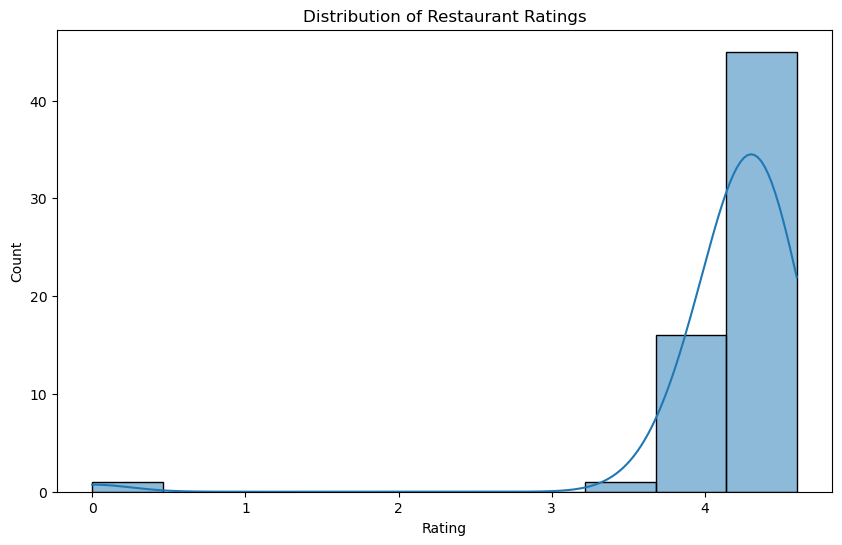

In [68]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Rating'],
    bins=10,
    kde=True
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

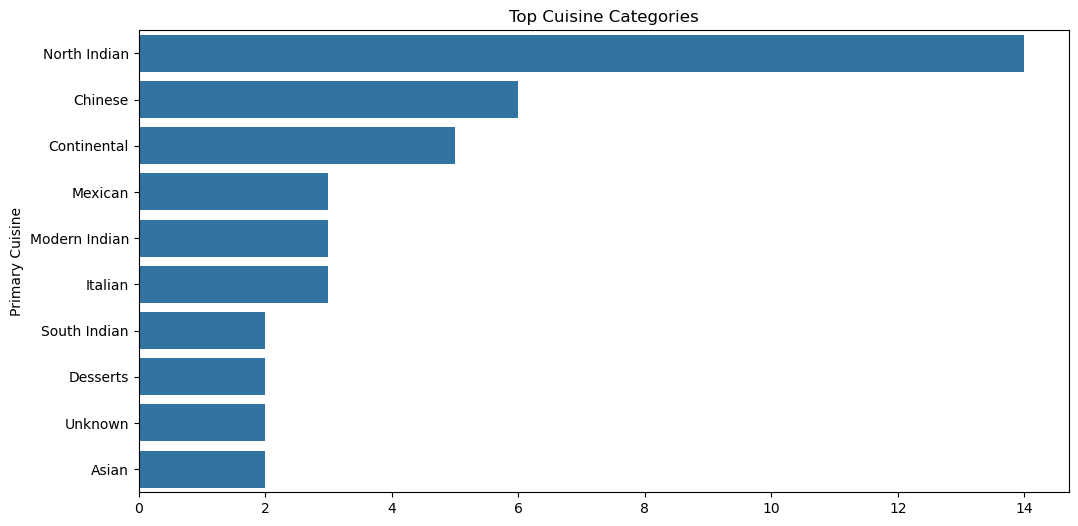

In [69]:
top_cuisine = df['Primary Cuisine'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cuisine.values,
    y=top_cuisine.index
)

plt.title("Top Cuisine Categories")

plt.show()

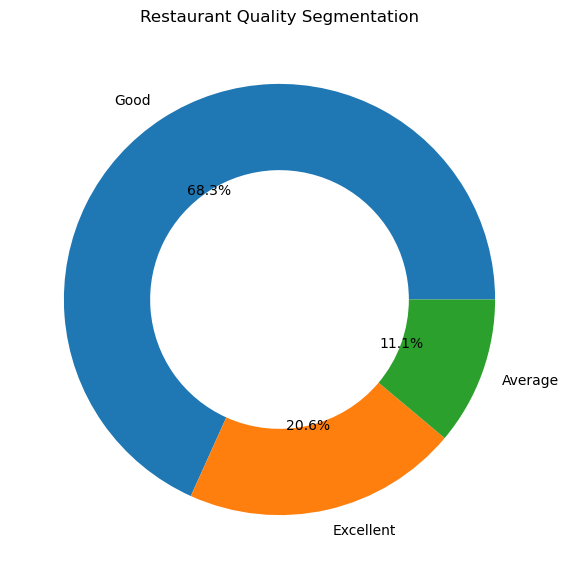

In [71]:
rating_counts = df['Rating Category'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Restaurant Quality Segmentation")

plt.show()

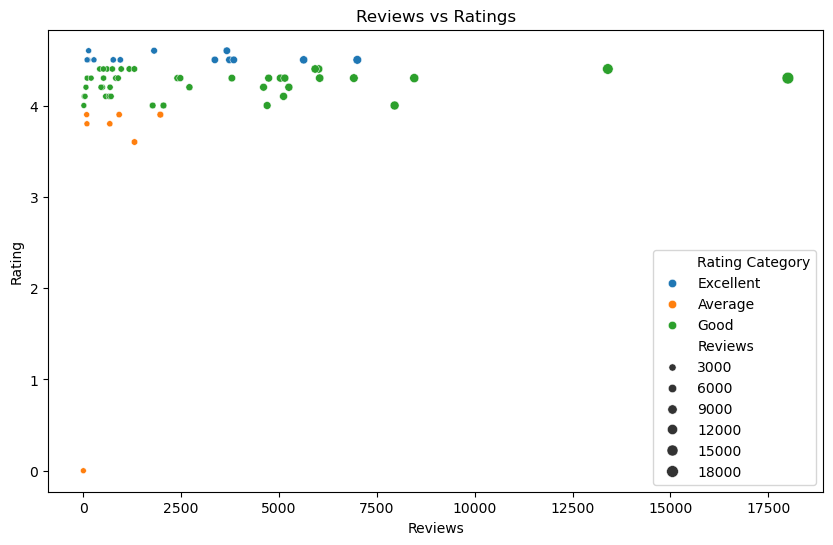

In [72]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Reviews',
    y='Rating',
    hue='Rating Category',
    size='Reviews',
    data=df
)

plt.title("Reviews vs Ratings")

plt.show()

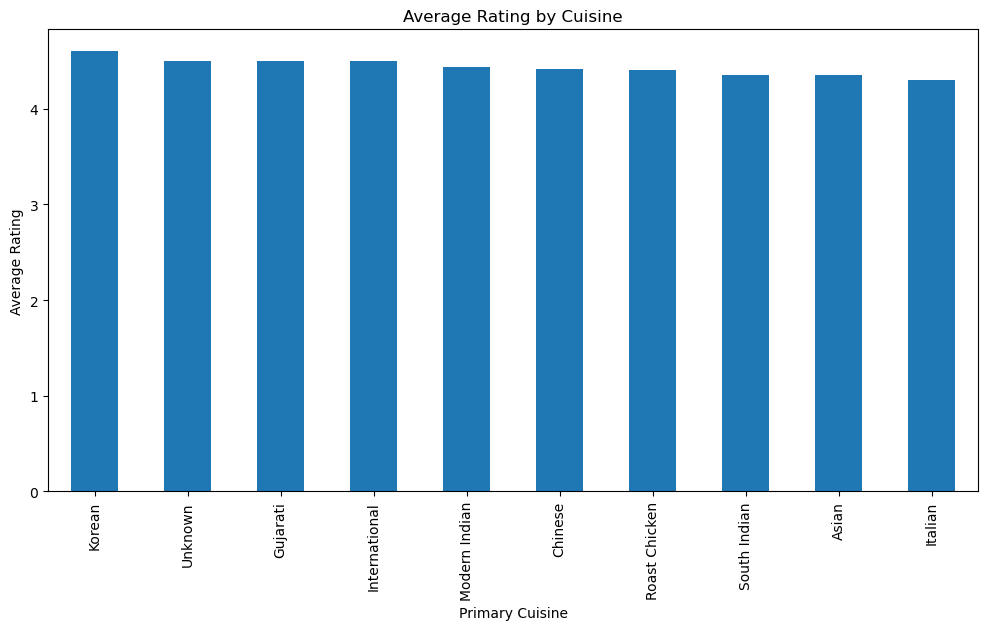

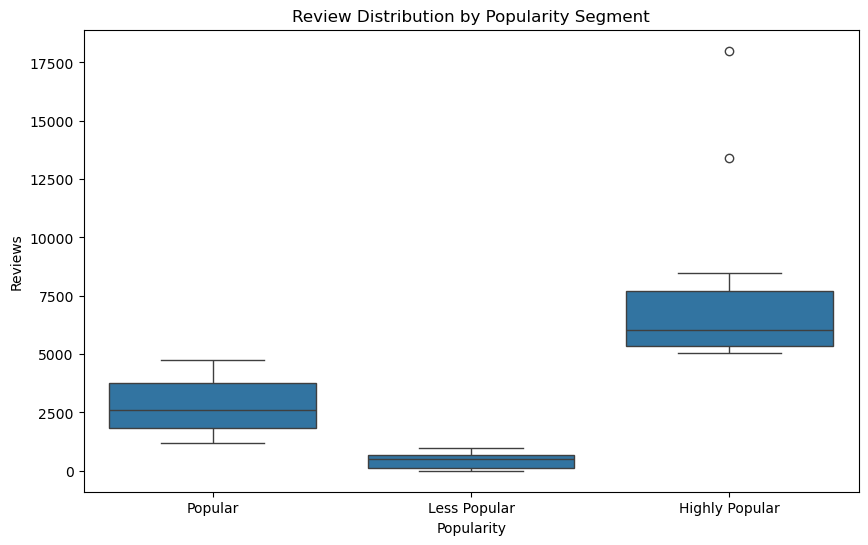

In [76]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Popularity',
    y='Reviews',
    data=df
)

plt.title("Review Distribution by Popularity Segment")

plt.show()

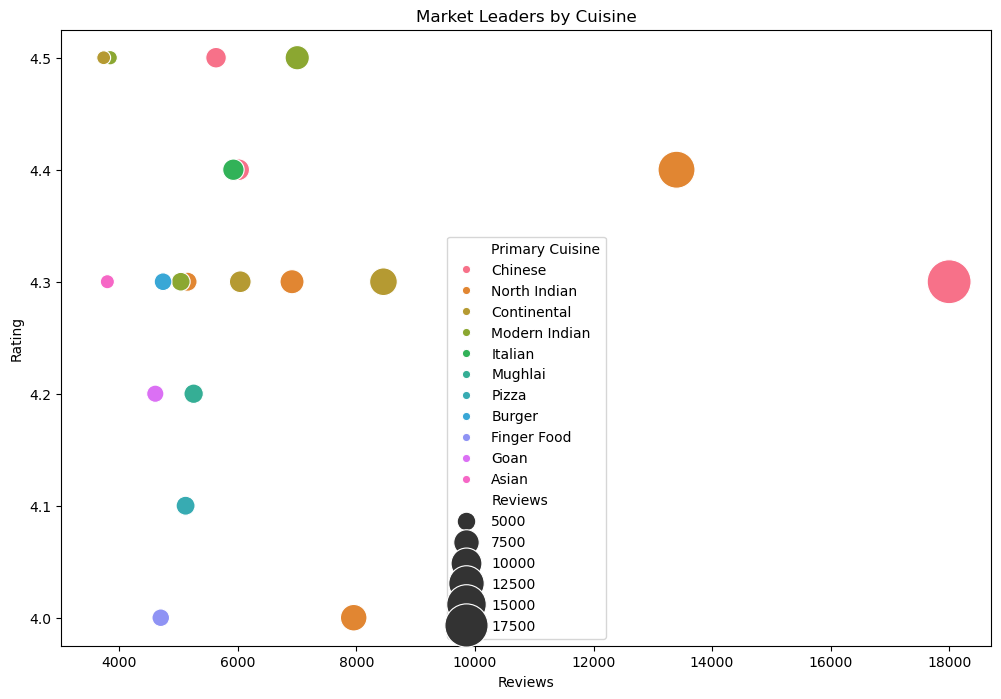

In [77]:
top_restaurants = df.sort_values(
    by='Reviews',
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.scatterplot(
    x='Reviews',
    y='Rating',
    size='Reviews',
    hue='Primary Cuisine',
    data=top_restaurants,
    sizes=(100,1000)
)

plt.title("Market Leaders by Cuisine")

plt.show()

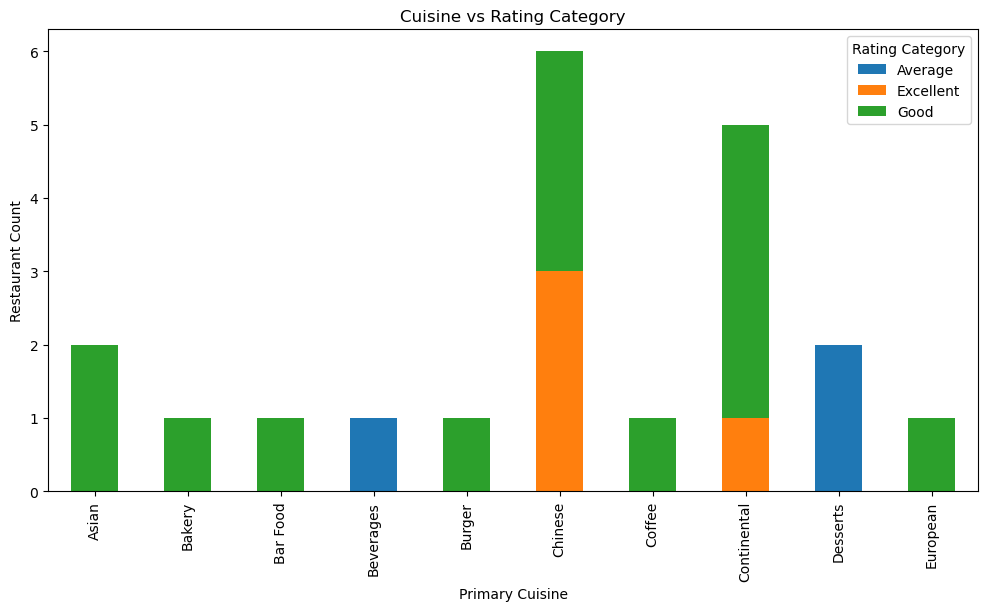

In [79]:
cross_tab = pd.crosstab(
    df['Primary Cuisine'],
    df['Rating Category']
)

cross_tab.head(10).plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Cuisine vs Rating Category")

plt.ylabel("Restaurant Count")

plt.show()

# Project Objectives

## Primary Objective

To analyze restaurant trends, customer preferences, and business performance using web scraping and exploratory data analysis techniques on restaurant data collected from Zomato.

---

## Specific Objectives

### Objective 1

Analyze customer satisfaction using restaurant ratings and review patterns.

### Objective 2

Identify the most popular cuisines and dining preferences among customers.

### Objective 3

Study the relationship between restaurant popularity and customer ratings.

### Objective 4

Analyze location-wise restaurant concentration and customer engagement.

### Objective 5

Identify premium and high-performing restaurant categories.

### Objective 6

Detect hidden growth opportunities through underrated restaurants.

### Objective 7

Generate business recommendations using data-driven insights.

---

# Business Insights

## Insight 1 — Customer Ratings are Highly Concentrated Between 4.0–4.5

Most restaurants fall within the 4.0 to 4.5 rating range, indicating strong competition and generally high customer expectations in the restaurant industry.

Business Meaning:
Restaurants must maintain consistent food quality and service standards to remain competitive.

---

## Insight 2 — North Indian Cuisine Dominates the Market

North Indian cuisine appears most frequently across restaurants, showing strong customer demand and market saturation.

Business Meaning:
Although demand is high, competition is also intense in this category.

---

## Insight 3 — Premium Cuisines Achieve Higher Ratings

Modern Indian, Asian, Continental, and Turkish cuisines tend to receive higher average ratings compared to mainstream cuisines.

Business Meaning:
Customers are increasingly preferring premium dining experiences and unique food concepts.

---

## Insight 4 — High Reviews Do Not Always Mean High Ratings

Some restaurants receive very high customer engagement but maintain average ratings.

Business Meaning:
Popularity alone does not guarantee customer satisfaction.

---

## Insight 5 — Highly Rated Restaurants with Low Reviews Represent Hidden Gems

Several restaurants have excellent ratings but relatively low review counts.

Business Meaning:
These restaurants have strong growth potential but limited digital visibility.

---

## Insight 6 — Customer Engagement is Unevenly Distributed

A small number of restaurants attract the majority of customer reviews and online engagement.

Business Meaning:
Brand recognition and online presence significantly influence restaurant popularity.

---

## Insight 7 — Cuisine Diversity Positively Impacts Engagement

Restaurants offering multiple cuisine options generally receive more customer reviews.

Business Meaning:
Menu diversification can improve customer reach and engagement.

---

## Insight 8 — Certain Locations Attract Premium Restaurants

Specific restaurant locations show consistently higher ratings and engagement.

Business Meaning:
Location selection plays a critical role in restaurant success.

---

# Conclusion

This project successfully demonstrated how web scraping and exploratory data analysis can be used to extract meaningful business insights from restaurant data collected from Zomato.

The analysis revealed strong customer preference patterns, cuisine trends, restaurant popularity factors, and rating behaviors. The study also identified highly competitive cuisine categories, premium dining trends, and hidden growth opportunities within the restaurant industry.

Using advanced EDA techniques such as univariate, bivariate, and multivariate analysis, the project provided a deeper understanding of customer engagement and restaurant performance.

Overall, the project highlights the importance of:

* Customer satisfaction
* Online visibility
* Cuisine strategy
* Location intelligence
* Data-driven decision making

in achieving restaurant business success.

---

# Recommendations

## Recommendation 1 — Improve Digital Visibility

Restaurants with high ratings but low reviews should focus on:

* social media marketing
* online promotions
* influencer collaborations
* customer engagement campaigns

to increase visibility and customer reach.

---

## Recommendation 2 — Differentiate in Saturated Cuisine Markets

Restaurants operating in highly competitive cuisine categories such as North Indian should:

* introduce unique menu items
* improve customer experience
* create premium dining concepts

to stand out from competitors.

---

## Recommendation 3 — Focus on Customer Experience

Since ratings strongly influence restaurant reputation, businesses should prioritize:

* food quality
* service quality
* hygiene
* ambiance
* delivery performance

to maintain strong customer satisfaction.

---

## Recommendation 4 — Expand Premium Cuisine Offerings

Premium cuisines such as Asian, Modern Indian, and Continental show strong customer response.

Restaurants can capitalize on this trend by:

* introducing fusion menus
* premium dining experiences
* specialty food concepts

---

## Recommendation 5 — Use Customer Reviews for Strategic Decisions

Restaurants should continuously monitor customer feedback and reviews to:

* identify operational issues
* improve menu offerings
* enhance service quality
* increase customer retention

---

## Recommendation 6 — Optimize Menu Diversity

Restaurants offering multiple cuisine choices tend to attract broader customer engagement.

Businesses should strategically diversify menus while maintaining food quality consistency.

---

## Recommendation 7 — Choose High-Potential Locations

Location analysis indicates that restaurant success is strongly influenced by area popularity and customer traffic.

Future restaurant expansion should focus on:

* high-engagement zones
* premium dining areas
* developing commercial hubs

to maximize business performance.
